# Figure 2A

Representative game trajectories from the highest-performing sessions.

In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sys
sys.path.append("../src")

import warnings
warnings.filterwarnings("ignore")

from Config.config import PATHS
from Utils.indices import AlternationIndex
from Utils.utils import GetMeasurements
from Utils.bar_utils import BarRenderer

In [57]:
path_to_data = PATHS['human_data'] / 'multi-player.csv'
data = pd.read_csv(path_to_data)
data['model'] = data.apply(lambda row: f"{row['num_players']}-{row['threshold']:.2f}-{row['group']}", axis=1)


In [58]:
gm = GetMeasurements(
    data=data, 
    measures=[
        'bounded_efficiency', 'entropy',
        'inequality', 'conditional_entropy', 'conditional_entropy_2nd_order', 'min_entropy'
    ],
    T=20
)
gm.columns.append('session')
gm.columns.append('approx_threshold')
print(gm.columns)
df = gm.get_measurements()
df['model'] = df.apply(lambda row: f"{row['num_players']}-{row['threshold']:.2f}-{row['group']}", axis=1)
df.head(2)

['model', 'treatment', 'threshold', 'num_players', 'group', 'session', 'approx_threshold']


,model,treatment,threshold,num_players,group,session,approx_threshold,bounded_efficiency,entropy,inequality,conditional_entropy,conditional_entropy_2nd_order,min_entropy
0,11-0.27-13,upwards,0.272727,11,13,1,0.25,-0.793651,0.403457,0.140236,0.009091,0.0,0.0
1,11-0.45-13,upwards,0.454545,11,13,2,0.50,-0.964286,0.403457,0.197803,0.009091,0.0,0.0


In [59]:
ai = AlternationIndex.from_file(priority='mlp')
df['predicted_class'] = ai.classify(df)
df.head(2)

,model,treatment,threshold,num_players,group,session,approx_threshold,bounded_efficiency,entropy,inequality,conditional_entropy,conditional_entropy_2nd_order,min_entropy,predicted_class
0,11-0.27-13,upwards,0.272727,11,13,1,0.25,-0.793651,0.403457,0.140236,0.009091,0.0,0.0,random
1,11-0.45-13,upwards,0.454545,11,13,2,0.50,-0.964286,0.403457,0.197803,0.009091,0.0,0.0,random


In [63]:
def get_category(group_model):
    category = df[df['model'] == group_model]['predicted_class']
    category = category.tolist()
    assert len(category) == 1, f"Error: model {group_model} does not have exactly one category"
    return category[0]

def get_bounded_efficiency(group_model):
    bounded_efficiency = df[df['model'] == group_model]['bounded_efficiency']
    bounded_efficiency = bounded_efficiency.tolist()
    assert len(bounded_efficiency) == 1, f"Error: model {group_model} does not exactly have one bounded efficiency"
    return bounded_efficiency[0]


In [61]:
df_best = df[df['bounded_efficiency'] > -10]
df_best = df_best[df_best['threshold'] < 1]

# df_best['model'] = df_best.apply(lambda row: f"{row['model']}-{row['num_players']}-{row['threshold']:.2f}", axis=1)
df_best.sort_values(by=['bounded_efficiency', 'num_players'], ascending=False, inplace=True)
print('Num. of best sessions:', len(df_best))


Num. of best sessions: 99


In [64]:
groups = df_best['model'].unique()
# groups = df_best[df_best['num_players'] == 5]['model'].unique()
excluded_groups = [
    '2-0.50-Grupo-0001', 
    '2-0.50-Grupo-0003', 
    '2-0.50-Grupo-0005', 
    '2-0.50-Grupo-0008', 
    '2-0.50-Grupo-0009', 
    '2-0.50-Grupo-0011', 
    '2-0.50-Grupo-0012', 
    '2-0.50-Grupo-0013', 
    '2-0.50-Grupo-0014',
    '2-0.50-Grupo-0015',
]
groups = [group for group in groups if group not in excluded_groups]
groups = [
    '2-0.50-Grupo-0006',
    '2-0.50-Grupo-0021',
    '2-0.50-Grupo-0010',
    '3-0.33-30',
    '3-0.67-24',
    '3-0.33-41',
    '4-0.25-25',
    '4-0.75-15',
    '4-0.75-27',
    '4-0.50-5',
    '5-0.80-14',
    '5-0.60-26',
]
# categories = [
#     'alternation', 
#     'alternation', 
#     'segmentation',
#     'segmentation',
#     'segmentation',
#     'mixed', 
#     'mixed', 
#     'mixed', 
# ]
categories = [get_category(group_model) for group_model in groups]
for category, group in zip(categories, groups):
    print(group, "->", category)

2-0.50-Grupo-0006 -> alternation
2-0.50-Grupo-0021 -> segmentation
2-0.50-Grupo-0010 -> random
3-0.33-30 -> alternation
3-0.67-24 -> segmentation
3-0.33-41 -> random
4-0.25-25 -> segmentation
4-0.75-15 -> mixed
4-0.75-27 -> mixed
4-0.50-5 -> random
5-0.80-14 -> mixed
5-0.60-26 -> random


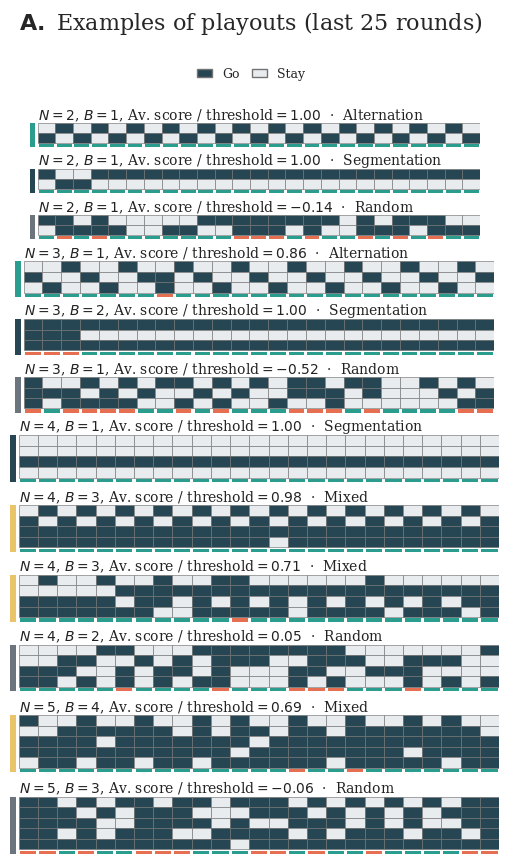

In [69]:
# Publication styling for best-session playouts
import matplotlib.patches as mpatches

sns.set_theme(style='ticks', font_scale=1.0)
plt.rcParams.update({
    'font.family': 'serif',
    'axes.titlesize': 9,
    'axes.labelsize': 9,
})

TYPE_LABELS = {
    'alternation': 'Alternation',
    'segmentation': 'Segmentation',
    'mixed': 'Mixed',
    'random': 'Random',
}
TYPE_COLORS = {
    'alternation': '#2A9D8F',
    'segmentation': '#264653',
    'mixed': '#E9C46A',
    'random': '#6C757D',
}
GO_COLOR = '#264653'
STAY_COLOR = '#E9ECEF'

panel_meta = []
for i, group in enumerate(groups):
    df_aux = df_best[df_best['model'] == group]
    df_aux_aux = data[data['model'] == group]
    N = int(df_aux_aux['num_players'].values[0])
    B = int(df_aux_aux['threshold'].values[0] * N)
    BE = float(df_aux['bounded_efficiency'].unique()[0])
    panel_meta.append({
        'group': group,
        'data': df_aux_aux,
        'N': N,
        'B': B,
        'BE': BE,
        'session_type': categories[i],
    })

height_ratios = [m['N'] for m in panel_meta]
fig, axes = plt.subplots(
    len(panel_meta), 1,
    figsize=(6.2, 9.5),
    gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.55},
)
num_rounds = 25

for i, meta in enumerate(panel_meta):
    type_label = TYPE_LABELS.get(meta['session_type'], meta['session_type'].title())
    type_color = TYPE_COLORS.get(meta['session_type'], '#333333')
    title = (
        rf"$N={meta['N']}$, $B={meta['B']}$, "
        rf"Av. score / threshold$={meta['BE']:.2f}$  ·  {type_label}"
    )

    bar_renderer = BarRenderer(data=meta['data'])
    bar_renderer.go_color = GO_COLOR
    bar_renderer.no_go_color = STAY_COLOR
    bar_renderer.edgecolor = '0.45'
    bar_renderer.edge_linewidth = 0.45
    bar_renderer.render(
        ax=axes[i],
        title=title,
        num_rounds=num_rounds,
        title_kwargs={'color': '#222222', 'loc': 'left', 'pad': 2, 'fontsize':10},
    )
    axes[i].add_patch(mpatches.Rectangle(
        (-0.018, 0), 0.012, 1,
        transform=axes[i].transAxes,
        facecolor=type_color, edgecolor='none',
        clip_on=False, zorder=10,
    ))

legend_handles = [
    mpatches.Patch(facecolor=GO_COLOR, edgecolor='0.45', label='Go'),
    mpatches.Patch(facecolor=STAY_COLOR, edgecolor='0.45', label='Stay'),
]
fig.suptitle(fr'$\mathbf{{A.}}$ Examples of playouts (last {num_rounds} rounds)', y=1.0, fontsize=16)
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=2,
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, 0.92),
    borderaxespad=0,
    handlelength=1.2,
    columnspacing=1.0,
)
fig.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()


In [71]:
fig.savefig(PATHS['exploratory_figures'] / 'Fig2A.png', dpi=300, bbox_inches='tight')